In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

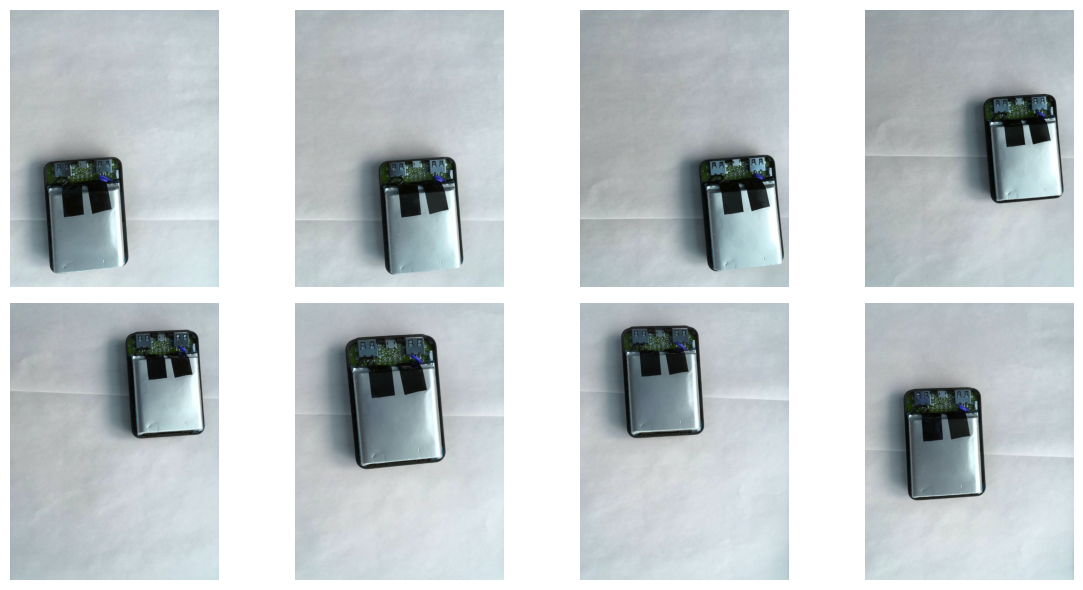

In [3]:
#Загружаем изначальное изображение
img_1 = cv2.imread('images/photo1.jpg')
img_2 = cv2.imread('images/photo2.jpg')
img_3 = cv2.imread('images/photo3.jpg')
img_4 = cv2.imread('images/photo4.jpg')
img_5 = cv2.imread('images/photo5.jpg')
img_6 = cv2.imread('images/photo6.jpg')
img_7 = cv2.imread('images/photo7.jpg')
img_8 = cv2.imread('images/photo8.jpg')
img_all = [img_1, img_2, img_3, img_4, img_5, img_6, img_7, img_8]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))  # 2 строки, 4 столбца, размер фигуры
for i, ax in enumerate(axes.flat):
    if i < len(img_all):
        ax.imshow(img_all[i])
    ax.axis('off')
plt.tight_layout()  # автоматически подгоняет отступы
plt.show()

In [4]:
def border(img, kernel_size):
    #Извлекает размеры изображения: rows — высота, cols — ширина.
    rows = img.shape[0]
    cols = img.shape[1]
    channels = img.shape[2]
    step_border = kernel_size // 2
    border_matrix = np.zeros((rows + step_border * 2, cols + step_border * 2, channels), dtype=np.uint8)

    for i in range(rows):
        for j in range(cols):
           for k in range(channels):
               border_matrix[i+step_border, j+step_border, k] = img[i,j,k]
               
    return border_matrix

In [5]:
def normal(kernel):
    rows = kernel.shape[0]
    cols = kernel.shape[1]
    sum = 0.0
    for i in range(rows):
        for j in range(rows):
            sum += kernel[i,j]
    for i in range(rows):
        for j in range(rows):
            kernel[i,j] = kernel[i,j] / sum
    
    return(kernel)

In [6]:
#Функция для заполнения матрицы свёртки, согласно переданной размерности матрицы и сигме (среднеквадратическое отклонение)
def gaussian_kernel(size, sigma):
    #Всё по классике, создаём нулевой массив в зависимости от переданной размерности, который в дальнейшем заполним значениями согласно функции Гаусса
    kernel = np.zeros((size, size))
    #Находим центр с помощью целочисленного деления для дальнейшего определечния координат точки для заполнения матрицы свёртки
    center = size // 2
    #Часть функции прорешиваем отдельно до цикла, чтобы минимизировать вычисления
    half = 1.0 / (2 * np.pi * sigma**2)

    for i in range(size):
        for j in range(size):
            x = i - center
            y = j - center
            #Прорешиваем остальную часть функции
            kernel[i, j] = half * np.exp(-(x**2 + y**2) / (2 * sigma**2))
    
    end_kernel = normal(kernel)
    return end_kernel

In [7]:
def gaussian_filter(img, kernel_size, sigma):
    
    kernel = gaussian_kernel(kernel_size, sigma)

    rows = img.shape[0]
    cols = img.shape[1]
    channels = img.shape[2]
    
    padded = border(img, kernel_size)
    result = np.zeros_like(img)
    
    for i in range(rows):
        for j in range(cols):
            window = padded[i:i+kernel_size, j:j+kernel_size]
            for c in range(channels):
                result[i, j, c] = np.sum(window[:, :, c] * kernel)
    
    return np.clip(result, 0, 255).astype(np.uint8)

In [34]:
img_gaus = [] 
for img in img_all:
    i1 = gaussian_filter(img, 3,1)   
    img_gaus.append(i1)   

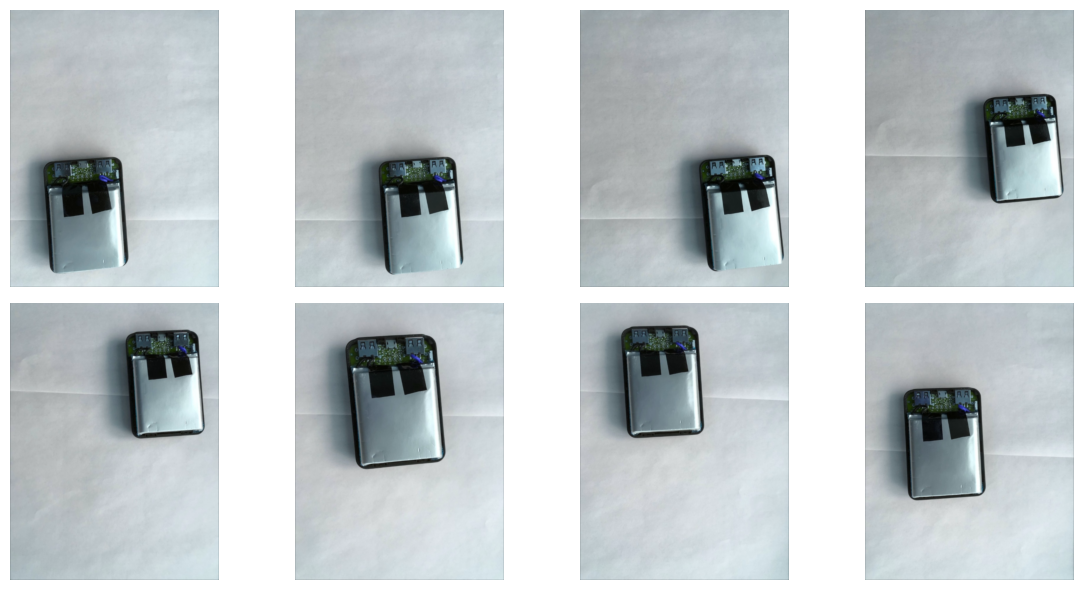

In [35]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))  # 2 строки, 4 столбца, размер фигуры
for i, ax in enumerate(axes.flat):
    if i < len(img_gaus):
        ax.imshow(img_gaus[i])
    ax.axis('off')
plt.tight_layout()  # автоматически подгоняет отступы
plt.show()

In [36]:
def bgr2rgb(img):
    rgb_img = img.copy()
    rgb_img[:,:,0] = img[:,:,2].copy()
    rgb_img[:,:,2] = img[:,:,0].copy()
    return rgb_img

In [37]:
def rgb_to_gray(img):  
    r = img[:,:,0]
    g = img[:,:,1]
    b = img[:,:,2]
    #Человеческий глаз по-разному чувствителен к разным цветам.Коэффициенты 0.299, 0.587 и 0.114 отражают эту разницу в восприятии. 
    #Они взяты из международного стандарта телевидения (ITU-R BT.601) 
    gray = 0.299 * r + 0.587 * g + 0.114 * b
    return gray.astype(np.uint8)

In [38]:
#Переведём 3 канальное изображение в один канал (отенки серого)
def transfer(img_all):
    img_grey = [] 
    for img in img_all:
        i1 = bgr2rgb(img) 
        i2 = rgb_to_gray(i1)    
        img_grey.append(i2)    
    return img_grey
img_grey = transfer(img_gaus)

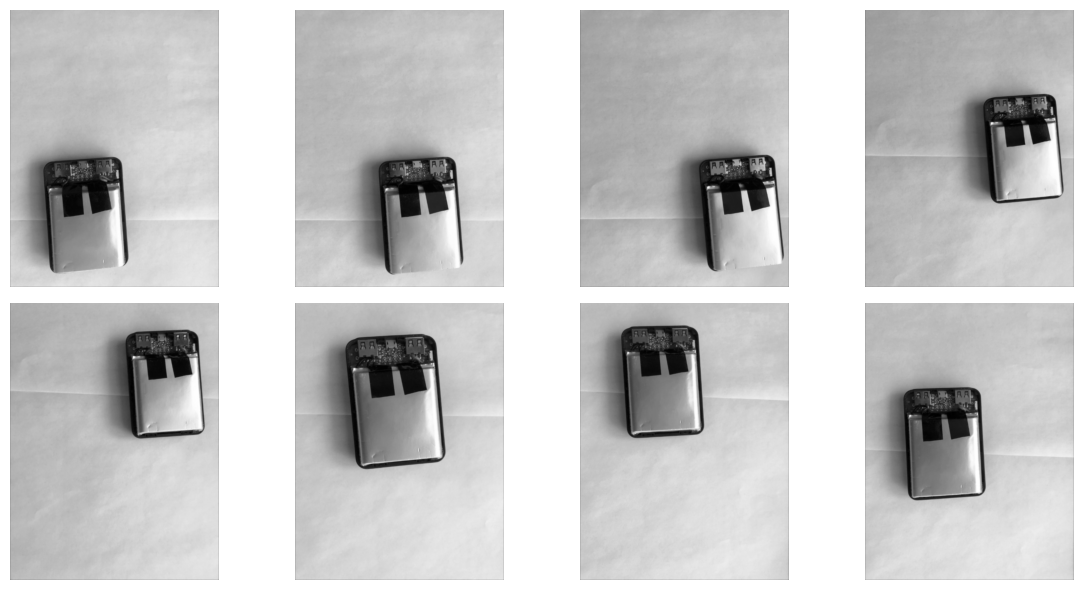

In [39]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))  # 2 строки, 4 столбца, размер фигуры
for i, ax in enumerate(axes.flat):
    if i < len(img_grey):
        ax.imshow(img_grey[i], cmap='gray')
    ax.axis('off')
plt.tight_layout()  # автоматически подгоняет отступы
plt.show()

Найдём градиенты по осям изображения

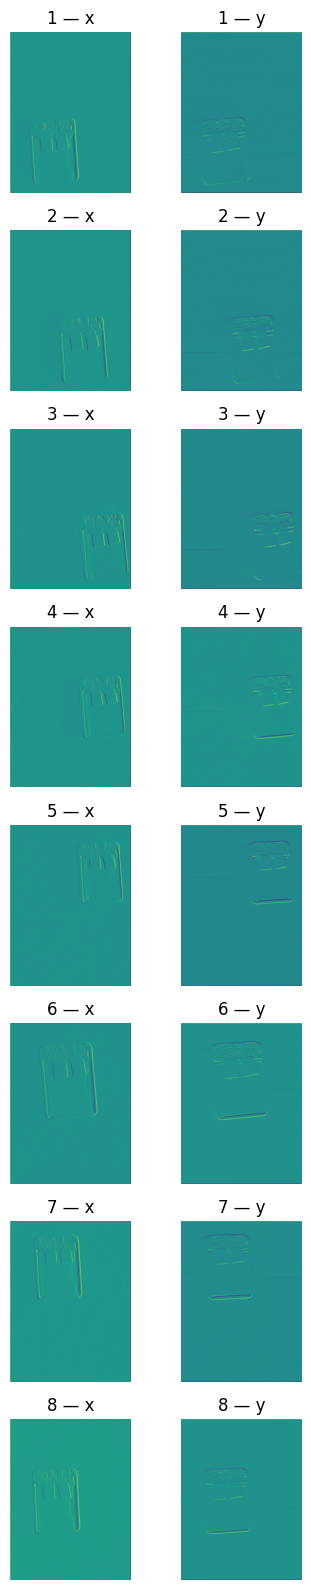

In [80]:
n = len(img_grey)

fig, axes = plt.subplots(n, 2, figsize=(4, 2*n))  # n строк, 2 столбца
for i, ax_row in enumerate(axes):
    img = img_grey[i].astype(np.float64)
    gy, gx = np.gradient(img)          # gy — по Y, gx — по X
    
    ax_row[0].imshow(gx)
    ax_row[0].set_title(f'{i+1} — x')
    ax_row[0].axis('off')
    
    ax_row[1].imshow(gy)
    ax_row[1].set_title(f'{i+1} — y')
    ax_row[1].axis('off')

plt.tight_layout()

In [40]:
windowSize = 11

In [41]:
def convolution(image, window):
    """Свёртка изображения с ядром window (суммирование по окну)"""
    start = int((windowSize-1)/2)
    result = np.zeros(image.shape, dtype=np.float64)
    for i in range(start, image.shape[0]-start):
        for j in range(start, image.shape[1]-start):
            # вырезаем окно и умножаем поэлементно на ядро, затем суммируем
            result[i, j] = np.sum(image[i-start:i+start+1, j-start:j+start+1] * window)
    return result

In [42]:
def local_max(e, window):
    """Поиск локальных максимумов на карте отклика e"""
    start = int((windowSize-1)/2)
    corner = dict()
    for i in range(start, e.shape[0]-start):
        for j in range(start, e.shape[1]-start):
            # окрестность вокруг пикселя
            x = e[i-start:i+start+1, j-start:j+start+1]
            if e[i, j] == np.max(x):
                # ключ - значение отклика, значение - координаты (j, i)
                corner[e[i, j]] = [j, i]
    return corner


In [59]:
def corner_detect(image, nCorners, windowSize):
    """
    Обнаружение углов методом Харриса (через минимальное собственное число)
    image - одноканальное изображение (серая шкала) уже без шума
    """
    # 1. Градиенты (без дополнительного размытия, так как изображение уже сглажено)
    dy, dx = np.gradient(image.astype(np.float64))
    plt.imshow(dy)
    plt.imshow(dx)
    # 2. Подготовка окна-единицы для суммирования
    window = np.ones((windowSize, windowSize))
    
    # 3. Компоненты структурного тензора
    c_xx = convolution(dx*dx, window)
    c_yy = convolution(dy*dy, window)
    c_xy = convolution(dx*dy, window)
    
    # 4. Мера угловатости = минимальное собственное число
    e = np.zeros(image.shape, dtype=np.float64)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            M = np.array([[c_xx[i, j], c_xy[i, j]],
                          [c_xy[i, j], c_yy[i, j]]])
            eigenvals, _ = np.linalg.eig(M)
            e[i, j] = np.min(eigenvals)
    
    # 5. Локальные максимумы
    corners_dict = local_max(e, window)
    
    # 6. Сортировка и отбор лучших
    corners = []
    for key in sorted(corners_dict.keys(), reverse=True):
        corners.append(corners_dict[key])
    return np.array(corners[:nCorners])

Изображение 1: найдено 25 углов
Изображение 2: найдено 25 углов
Изображение 3: найдено 25 углов
Изображение 4: найдено 25 углов
Изображение 5: найдено 25 углов
Изображение 6: найдено 25 углов
Изображение 7: найдено 25 углов
Изображение 8: найдено 25 углов


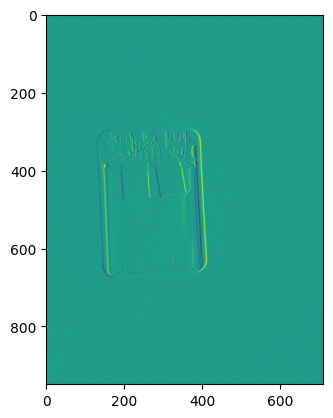

In [81]:
all_corners = []
for i, gray_img in enumerate(img_grey):
    corners = corner_detect(gray_img, 25, windowSize)
    all_corners.append(corners)
    print(f"Изображение {i+1}: найдено {len(corners)} углов")

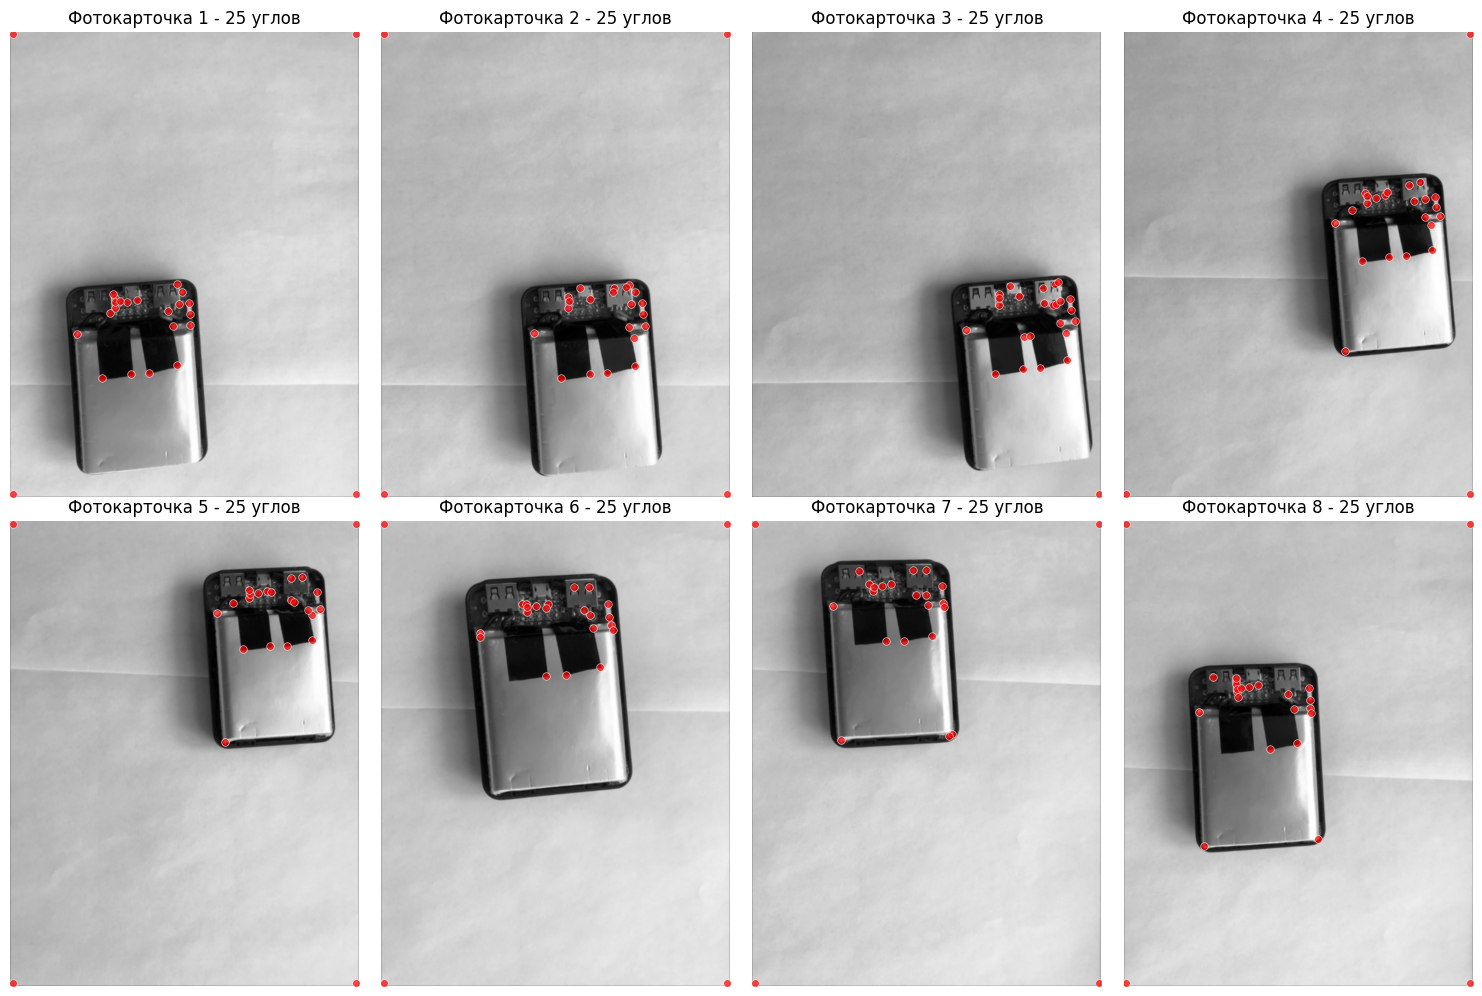

In [82]:
import matplotlib.pyplot as plt

# Количество изображений (у вас 8)
n_images = len(img_grey)
cols = 4
rows = (n_images + cols - 1) // cols   # 2 строки для 8 изображений

fig, axes = plt.subplots(rows, cols, figsize=(15, 10))
axes = axes.flatten()  # удобно перебирать

for i, ax in enumerate(axes):
    if i < n_images:
        # Отображаем серое изображение
        ax.imshow(img_grey[i], cmap='gray')
        # Получаем координаты углов для текущего изображения
        corners = all_corners[i]   # массив формы (N, 2) -> [x, y]
        if len(corners) > 0:
            # Разделяем координаты x и y
            xs = corners[:, 0]
            ys = corners[:, 1]
            ax.scatter(xs, ys, c='red', s=30, alpha=0.7, edgecolors='white', linewidth=0.5)
        ax.set_title(f'Фотокарточка {i+1} - {len(corners)} углов')
        ax.axis('off')
    else:
        ax.axis('off')  # скрываем пустые подграфики

plt.tight_layout()
plt.show()

Вычисление дескрипторов (SIFT-подобный метод)

In [83]:
#Вычисление магнитуды и ориентации градиента
def compute_gradient_orientation(gx, gy):
    magnitude = np.sqrt(gx**2 + gy**2)
    orientation = np.arctan2(gy, gx) * 180 / np.pi
    orientation[orientation < 0] += 360
    return magnitude, orientation

In [84]:
def sift_descriptor(img, x, y, patch_size, num_bins):

    half = patch_size // 2
    
    # Вырезаем патч
    patch = img[y-half:y+half, x-half:x+half].astype(np.float64)
    
    gx, gy = np.gradient(patch.astype(np.float64))
    # Градиенты через оператор Собеля
    
    # Магнитуда и ориентация
    magnitude, orientation = compute_gradient_orientation(gx, gy)
    
    # Разбиение на подобласти 4x4
    cell_size = patch_size // 4   # =4
    descriptor = []
    
    for i in range(4):
        for j in range(4):
            # Извлекаем подобласть
            cell_mag = magnitude[i*cell_size:(i+1)*cell_size,
                                 j*cell_size:(j+1)*cell_size]
            cell_ori = orientation[i*cell_size:(i+1)*cell_size,
                                   j*cell_size:(j+1)*cell_size]
            
            # Гистограмма ориентаций (8 бинов)
            hist = np.zeros(num_bins)
            bin_width = 360 / num_bins   # 45 градусов
            for m in range(cell_size):
                for n in range(cell_size):
                    bin_idx = int(cell_ori[m, n] / bin_width) % num_bins
                    hist[bin_idx] += cell_mag[m, n]
            
            # Нормализация гистограммы
            norm = np.linalg.norm(hist)
            if norm > 0:
                hist = hist / norm
            # Ограничение значений (как в SIFT)
            hist = np.clip(hist, 0, 0.2)
            # Повторная нормализация
            norm2 = np.linalg.norm(hist)
            if norm2 > 0:
                hist = hist / norm2
            
            descriptor.extend(hist)
    
    return np.array(descriptor)


In [85]:
def compare_descriptors(desc1, desc2, ratio_thresh):
    matches = []
    for i, d1 in enumerate(desc1):
        # Евклидовы расстояния до всех дескрипторов второго изображения
        distances = np.linalg.norm(desc2 - d1, axis=1)
        if len(distances) < 2:
            continue
        sorted_idx = np.argsort(distances)
        d1_best = distances[sorted_idx[0]]
        d2_best = distances[sorted_idx[1]]
        if d1_best < ratio_thresh * d2_best:
            matches.append((i, sorted_idx[0], d1_best))
    return matches

In [86]:
all_descriptors = []   # список дескрипторов для каждого изображения
valid_corners = []     # список координат углов, для которых удалось вычислить дескриптор

for i, img in enumerate(img_grey):
    desc_list = []
    corners_list = []
    for (x, y) in all_corners[i]:
        desc = sift_descriptor(img, x, y, 16, 8)
        desc_list.append(desc)
        corners_list.append((x, y))
    all_descriptors.append(np.array(desc_list))
    valid_corners.append(np.array(corners_list))

IndexError: index 2 is out of bounds for axis 1 with size 2

In [ ]:
all_matches = []
for i in range(len(img_grey)-1):
    matches = compare_descriptors(all_descriptors[i], all_descriptors[i+1], 0.85)
    all_matches.append(matches)
    print(f"{i+1}-{i+2}: {len(matches)}")

1-2: 11
2-3: 17
3-4: 12
4-5: 8
5-6: 10
6-7: 12
7-8: 8


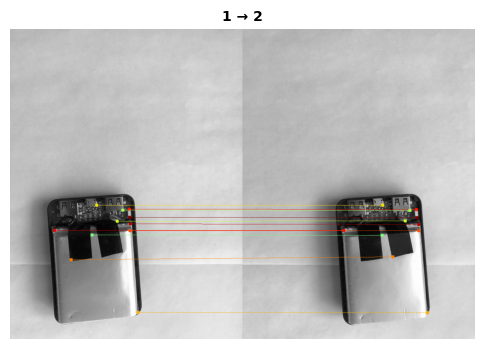

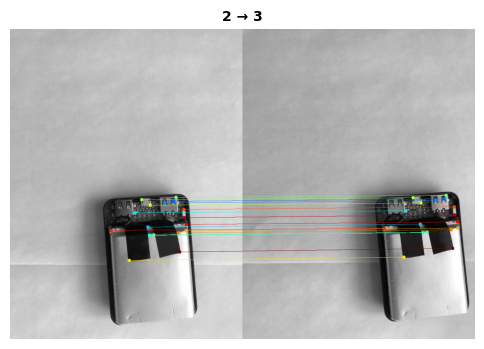

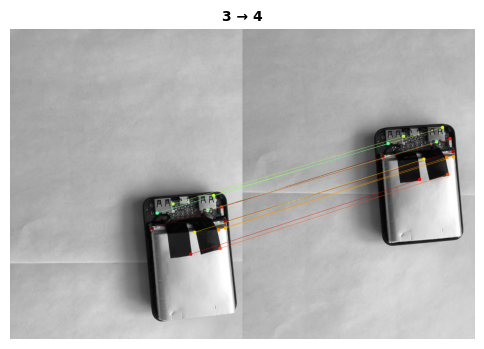

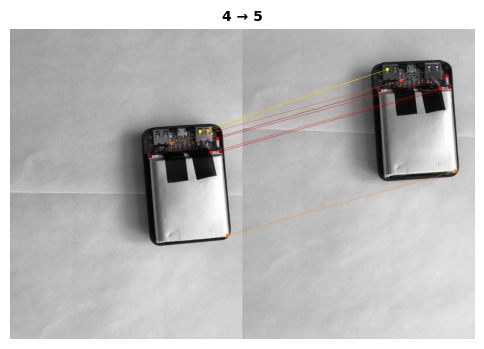

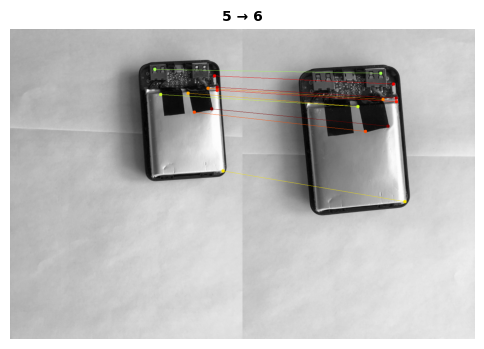

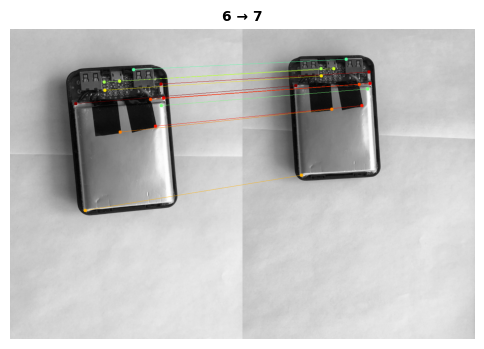

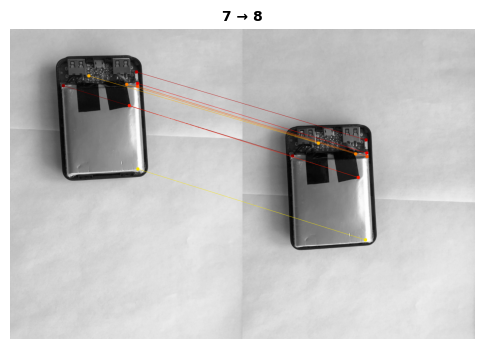

In [ ]:
# Визуализация сопоставленных точек
def show_matches(img1, img2, pts1, pts2, matches, title):
    # Склеиваем изображения
    vis = np.hstack([img1, img2])
    vis = cv2.cvtColor(vis, cv2.COLOR_GRAY2BGR)
    h, w = img1.shape
    
    # Рисуем сопоставления (не больше 20)
    for idx, (i, j, b) in enumerate(matches[:20]):
        # Цвет от красного (индекс 0) до фиолетового (индекс 19)
        color = plt.cm.jet(idx / 20)[:3]  # RGB от 0 до 1
        color = tuple(int(c * 255) for c in color)  # RGB -> BGR для OpenCV
        
        x1, y1 = pts1[i]
        x2, y2 = pts2[j]
        
        # Линия
        cv2.line(vis, (int(x1), int(y1)), (int(x2) + w, int(y2)), color, 1)
        # Круги
        cv2.circle(vis, (int(x1), int(y1)), 5, color, -1)
        cv2.circle(vis, (int(x2) + w, int(y2)), 5, color, -1)
    
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f'{title}', fontsize=10, fontweight='bold')
    plt.show()
# Сопоставление точек
for i, matches in enumerate(all_matches):
    if len(matches) > 0:
        show_matches(img_grey[i], img_grey[i+1], valid_corners[i], valid_corners[i+1], matches, f'{i+1} → {i+2}')













Оценка двжиения камеры (RANSAC) (аббр. RANdom SAmple Consensus) 

In [ ]:
def estimate_transform(matches, corners1, corners2):
    # Оценка аффинного преобразования методом наименьших квадратов
    # matches список сопоставлений (idx1, idx2, distance)
    # corners1, corners2 координаты ключевых точек
   
    if len(matches) < 3: # Проверяет, достаточно ли сопоставлений для надежной оценки преобразования
        # Для аффинного преобразования нужно минимум 3 пары точек (2×2 = 4 уравнения, но 6 неизвестных — нужно минимум 3 точки для решения)
        return None, (0, 0)
    
    # Собираем соответствующие точки. Пустые списки для хранения координат соответствующих точек
    pts1 = []
    pts2 = []
    
    for i, j, _ in matches:# Цикл по всем сопоставлениям
# i — индекс точки в первом изображении, j — индекс точки во втором изображении, _ — расстояние (не используется, поэтому игнорируется)
        pts1.append(corners1[i]) # Добавляет координаты точки из первого изображения в список
        pts2.append(corners2[j]) # Добавляет координаты соответствующей точки из второго изображения
    
    pts1 = np.array(pts1) # Преобразует списки в массивы NumPy для удобства вычислений. Формат pts1.shape = (N, 2), где N — количество сопоставлений
    pts2 = np.array(pts2)
    
    # Вычисляем среднее смещение
    translation = np.mean(pts2 - pts1, axis=0) # pts2 - pts1 — вычисляет вектор смещения для каждой пары точек (разность координат)
    # axis=0 — усредняет по всем точкам (по строкам), получая среднее смещение
    
    # Для аффинного преобразования нужна матрица 2x3
    # Но для простоты используем только смещение
    matrix = np.array([[1, 0, translation[0]],
                       [0, 1, translation[1]]])
    
    return matrix, translation
    # matrix — матрица преобразования 2×3, translation — вектор смещения (dx, dy)

In [ ]:
def ransac_transform(matches, corners1, corners2, n_iterations=100, threshold=10.0):
    # Оценка преобразования с использованием RANSAC

    # matches список сопоставлений (могут содержать ложные совпадения)
    # corners1, corners2 координаты ключевых точек
    # n_iterations количество итераций RANSAC (чем больше, тем надежнее, но медленнее)
    # threshold порог для определения inliers
  
    if len(matches) < 3: # Для аффинного преобразования нужно минимум 3 точки
        return None, (0, 0), [] # Возвращает матрицу, смещение, список inliers
    
    best_inliers = [] # Список для хранения лучших inliers (правильно сопоставленных точек)
    best_translation = (0, 0) # Лучшее найденное смещение
    
    for _ in range(n_iterations): # Выполняет заданное количество итераций
        # Выбираем 3 случайных уникальных индекса из всех сопоставлений
        sample_idx = random.sample(range(len(matches)), 3)
        sample_matches = [matches[i] for i in sample_idx] # Собирает выбранные случайные сопоставления
        
        # Оцениваем преобразование
        _, translation = estimate_transform(sample_matches, corners1, corners2) # Оценивает преобразование по случайной выборке
        # _ — матрица, translation — вычисленное смещени
        
        # Находим inliers
        inliers = [] # Список индексов точек, которые согласуются с текущей гипотезой
        for idx, (i, j, _) in enumerate(matches): # Проходит по всем сопоставлениям
# idx — индекс сопоставления в списке, i — индекс точки в первом изображении, j — индекс точки во втором изображении
            x1, y1 = corners1[i] # Координаты соответствующей пары точек
            x2, y2 = corners2[j]
            
            # Вычисляем ошибку
            error = np.sqrt((x2 - x1 - translation[0])**2 + 
                          (y2 - y1 - translation[1])**2)
            # Вычисляет расстояние между: предсказанной позицией (x1 + translation[0], y1 + translation[1]) и реальной позицией (x2, y2)

            if error < threshold: # Если ошибка меньше порога, точка считается inlier
                inliers.append(idx) # Добавляет индекс точки в список inliers
        
        if len(inliers) > len(best_inliers): # Если текущая гипотеза нашла больше inliers, чем предыдущая лучшая
            best_inliers = inliers # Сохраняет лучшую гипотезу
            best_translation = translation # Сохраняет лучшую гипотезу
    
    # Переоцениваем по всем inliers
    if len(best_inliers) >= 3: # Если найдено достаточно inliers (минимум 3)
        inlier_matches = [matches[i] for i in best_inliers] # Собирает все сопоставления, признанные inliers
        _, best_translation = estimate_transform(inlier_matches, corners1, corners2) # Повторно оценивает преобразование, используя все inliers
        # Это дает более точную оценку, чем по случайным 3 точкам
    
    best_matrix = np.array([[1, 0, best_translation[0]], # Создает матрицу трансляции из найденного смещения
                           [0, 1, best_translation[1]]])
    
    return best_matrix, best_translation, best_inliers # Возвращает матрицу преобразования, вектор смещения, список индексов inliers (для отладки и визуализации)

# Оцениваем преобразования между соседними изображениями
trajectory = [(0, 0)] # Список для хранения траектории движения камеры. Начинается с точки (0, 0) — начальная позиция
transformations = [] # Список для хранения матриц преобразований между кадрами

print("\nОценка смещений между кадрами (с RANSAC):")

for i, matches in enumerate(all_matches): # Проходит по всем парам соседних изображений
    if len(matches) >= 3: # Проверяет, достаточно ли сопоставлений для оценки (минимум 3)
        matrix, translation, inliers = ransac_transform( # Вызывает RANSAC для надежной оценки смещения
            matches, valid_corners[i], valid_corners[i+1]
        )
        
        last_point = trajectory[-1] # Получает последнюю точку траектории

        new_point = (last_point[0] + translation[0], # Вычисляет новую позицию, добавляя найденное смещение. Формирует траекторию движения камеры
                    last_point[1] + translation[1])
        trajectory.append(new_point) # Сохраняет новую позицию и матрицу преобразования
        transformations.append(matrix)
        
        print(f"   Кадр {i+1} → {i+2}:") # Выводит номер пары
        print(f"      Смещение: Δx = {translation[0]:.2f}, Δy = {translation[1]:.2f}") # Смещение между кадрами в пикселях
        print(f"      Inliers: {len(inliers)}/{len(matches)}") # Количество правильных сопоставлений / общее количество
        print(f"      Позиция: ({new_point[0]:.2f}, {new_point[1]:.2f})") # Накопленная позиция относительно начала
    else:
        trajectory.append(trajectory[-1])
        transformations.append(None)
        print(f"   Кадр {i+1} → {i+2}: недостаточно совпадений ({len(matches)})")


Оценка смещений между кадрами (с RANSAC):
   Кадр 1 → 2:
      Смещение: Δx = 170.30, Δy = 0.60
      Inliers: 10/11
      Позиция: (170.30, 0.60)
   Кадр 2 → 3:
      Смещение: Δx = 120.41, Δy = -7.82
      Inliers: 17/17
      Позиция: (290.71, -7.22)
   Кадр 3 → 4:
      Смещение: Δx = -11.10, Δy = -216.40
      Inliers: 10/12
      Позиция: (279.61, -223.62)
   Кадр 4 → 5:
      Смещение: Δx = -10.00, Δy = -196.17
      Inliers: 6/8
      Позиция: (269.61, -419.79)
   Кадр 5 → 6:
      Смещение: Δx = -166.75, Δy = 31.75
      Inliers: 4/10
      Позиция: (102.86, -388.04)
   Кадр 6 → 7:
      Смещение: Δx = -77.00, Δy = -44.75
      Inliers: 4/12
      Позиция: (25.86, -432.79)
   Кадр 7 → 8:
      Смещение: Δx = -10.50, Δy = 213.38
      Inliers: 8/8
      Позиция: (15.36, -219.42)


In [ ]:
def ransac_transform(matches, corners1, corners2, n_iterations=100, threshold=10.0):
    # Оценка преобразования с использованием RANSAC

    # matches список сопоставлений (могут содержать ложные совпадения)
    # corners1, corners2 координаты ключевых точек
    # n_iterations количество итераций RANSAC (чем больше, тем надежнее, но медленнее)
    # threshold порог для определения inliers
  
    if len(matches) < 3: # Для аффинного преобразования нужно минимум 3 точки
        return None, (0, 0), [] # Возвращает матрицу, смещение, список inliers
    
    best_inliers = [] # Список для хранения лучших inliers (правильно сопоставленных точек)
    best_translation = (0, 0) # Лучшее найденное смещение
    
    for _ in range(n_iterations): # Выполняет заданное количество итераций
        # Выбираем 3 случайных уникальных индекса из всех сопоставлений
        sample_idx = random.sample(range(len(matches)), 3)
        sample_matches = [matches[i] for i in sample_idx] # Собирает выбранные случайные сопоставления
        
        # Оцениваем преобразование
        _, translation = estimate_transform(sample_matches, corners1, corners2) # Оценивает преобразование по случайной выборке
        # _ — матрица, translation — вычисленное смещени
        
        # Находим inliers
        inliers = [] # Список индексов точек, которые согласуются с текущей гипотезой
        for idx, (i, j, _) in enumerate(matches): # Проходит по всем сопоставлениям
# idx — индекс сопоставления в списке, i — индекс точки в первом изображении, j — индекс точки во втором изображении
            x1, y1 = corners1[i] # Координаты соответствующей пары точек
            x2, y2 = corners2[j]
            
            # Вычисляем ошибку
            error = np.sqrt((x2 - x1 - translation[0])**2 + 
                          (y2 - y1 - translation[1])**2)
            # Вычисляет расстояние между: предсказанной позицией (x1 + translation[0], y1 + translation[1]) и реальной позицией (x2, y2)

            if error < threshold: # Если ошибка меньше порога, точка считается inlier
                inliers.append(idx) # Добавляет индекс точки в список inliers
        
        if len(inliers) > len(best_inliers): # Если текущая гипотеза нашла больше inliers, чем предыдущая лучшая
            best_inliers = inliers # Сохраняет лучшую гипотезу
            best_translation = translation # Сохраняет лучшую гипотезу
    
    # Переоцениваем по всем inliers
    if len(best_inliers) >= 3: # Если найдено достаточно inliers (минимум 3)
        inlier_matches = [matches[i] for i in best_inliers] # Собирает все сопоставления, признанные inliers
        _, best_translation = estimate_transform(inlier_matches, corners1, corners2) # Повторно оценивает преобразование, используя все inliers
        # Это дает более точную оценку, чем по случайным 3 точкам
    
    best_matrix = np.array([[1, 0, best_translation[0]], # Создает матрицу трансляции из найденного смещения
                           [0, 1, best_translation[1]]])
    
    return best_matrix, best_translation, best_inliers # Возвращает матрицу преобразования, вектор смещения, список индексов inliers (для отладки и визуализации)

# Оцениваем преобразования между соседними изображениями
trajectory = [(0, 0)] # Список для хранения траектории движения камеры. Начинается с точки (0, 0) — начальная позиция
transformations = [] # Список для хранения матриц преобразований между кадрами

print("\nОценка смещений между кадрами (с RANSAC):")

for i, matches in enumerate(all_matches): # Проходит по всем парам соседних изображений
    if len(matches) >= 3: # Проверяет, достаточно ли сопоставлений для оценки (минимум 3)
        matrix, translation, inliers = ransac_transform( # Вызывает RANSAC для надежной оценки смещения
            matches, valid_corners[i], valid_corners[i+1]
        )
        
        last_point = trajectory[-1] # Получает последнюю точку траектории

        new_point = (last_point[0] - translation[0], # Вычисляет новую позицию, добавляя найденное смещение. Формирует траекторию движения камеры
                    last_point[1] + translation[1])
        trajectory.append(new_point) # Сохраняет новую позицию и матрицу преобразования
        transformations.append(matrix)
        
        print(f"   Кадр {i+1} → {i+2}:") # Выводит номер пары
        print(f"      Смещение: Δx = {translation[0]:.2f}, Δy = {translation[1]:.2f}") # Смещение между кадрами в пикселях
        print(f"      Inliers: {len(inliers)}/{len(matches)}") # Количество правильных сопоставлений / общее количество
        print(f"      Позиция: ({new_point[0]:.2f}, {new_point[1]:.2f})") # Накопленная позиция относительно начала
    else:
        trajectory.append(trajectory[-1])
        transformations.append(None)
        print(f"   Кадр {i+1} → {i+2}: недостаточно совпадений ({len(matches)})")


Оценка смещений между кадрами (с RANSAC):
   Кадр 1 → 2:
      Смещение: Δx = 170.30, Δy = 0.60
      Inliers: 10/11
      Позиция: (-170.30, 0.60)
   Кадр 2 → 3:
      Смещение: Δx = 120.41, Δy = -7.82
      Inliers: 17/17
      Позиция: (-290.71, -7.22)
   Кадр 3 → 4:
      Смещение: Δx = -11.10, Δy = -216.40
      Inliers: 10/12
      Позиция: (-279.61, -223.62)
   Кадр 4 → 5:
      Смещение: Δx = -10.00, Δy = -196.17
      Inliers: 6/8
      Позиция: (-269.61, -419.79)
   Кадр 5 → 6:
      Смещение: Δx = -166.75, Δy = 31.75
      Inliers: 4/10
      Позиция: (-102.86, -388.04)
   Кадр 6 → 7:
      Смещение: Δx = -77.00, Δy = -44.75
      Inliers: 4/12
      Позиция: (-25.86, -432.79)
   Кадр 7 → 8:
      Смещение: Δx = -10.50, Δy = 213.38
      Inliers: 8/8
      Позиция: (-15.36, -219.42)


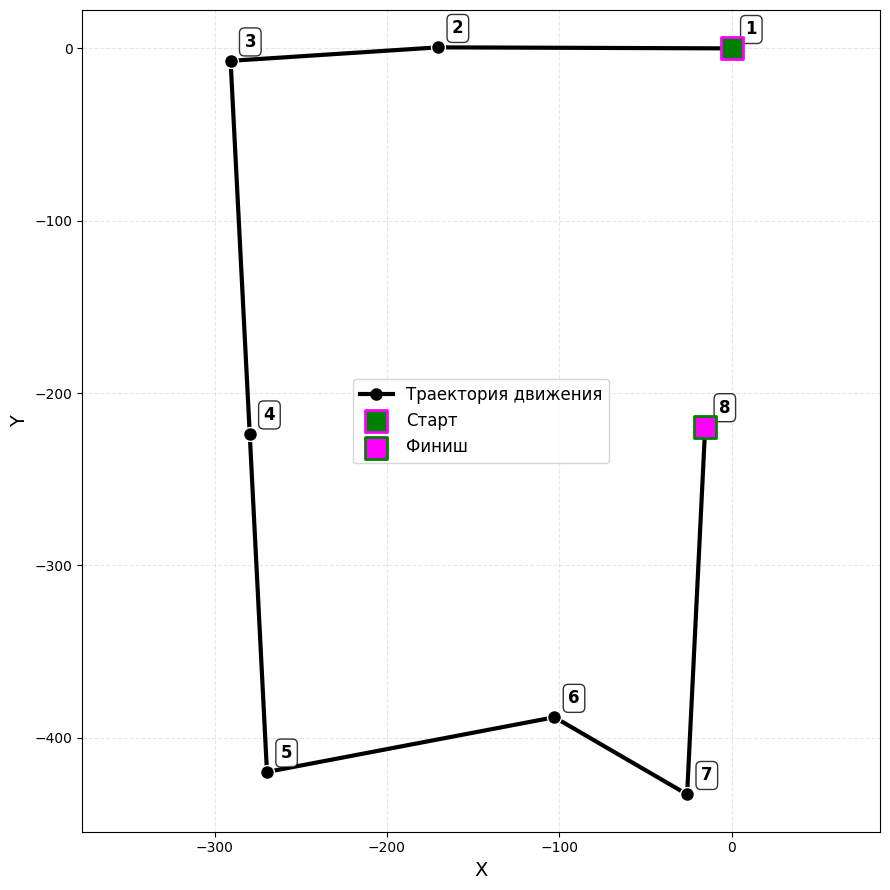

In [ ]:
# Траектория
trajectory_np = np.array(trajectory)
# Преобразует список trajectory в массив NumPy. Каждый элемент — это точка (x, y) накопленного смещения

plt.figure(figsize=(9, 9)) # квадратная область 9×9 дюймов

# Рисуем траекторию
plt.plot(trajectory_np[:, 0], trajectory_np[:, 1], 'k-o', linewidth=3, markersize=8, # trajectory_np[:, 0] — все X-координаты траектории
         label='Траектория движения', markeredgecolor='black', markeredgewidth=1)
# trajectory_np[:, 1] — все Y-координаты траектории, 'k-o' — стиль линии: k — черный цвет, o — кружок в каждой точке, - — сплошная линия между точками
# linewidth=3 — толщина линии 3 пикселя, markersize=8 — размер маркеров (кружков), markeredgecolor='black' — черная обводка маркеров
# markeredgewidth=1 — толщина обводки маркеров

# Отмечаем точки
plt.scatter(trajectory_np[0, 0], trajectory_np[0, 1], c='green', s=250, # s=250 — размер точки, marker='s' — квадратный маркер, edgecolors='black' — черная обводка
            marker='s', label='Старт', edgecolors='magenta', linewidth=2, zorder=5) # zorder=5 — порядок отрисовки (выше, чем у линии, чтобы быть поверх)
plt.scatter(trajectory_np[-1, 0], trajectory_np[-1, 1], c='magenta', s=250, 
            marker='s', label='Финиш', edgecolors='green', linewidth=2, zorder=5) # # -1 — индекс последнего элемента

# Добавляем промежуточные точки
plt.scatter(trajectory_np[1:-1, 0], trajectory_np[1:-1, 1], c='black', s=100, 
            edgecolors='white', linewidth=1, zorder=4) 
# trajectory_np[1:-1, 0] — все X-координаты, кроме первой и последней, trajectory_np[1:-1, 1] — все Y-координаты, кроме первой и последней
# s=100 — размер точек, edgecolors='white' — белая обводка, zorder=4 — чуть ниже старта/финиша (zorder=5), но выше линии

# Добавляем номера кадров
for i, (x, y) in enumerate(trajectory_np): # Цикл по всем точкам траектории
    plt.annotate(f'{i+1}', (x, y), xytext=(10, 10), # f'{i+1}' — номер кадра (начиная с 1), xytext=(10, 10) — смещение текста от точки на 10 пикселей вправо и вверх
                textcoords='offset points', fontsize=12, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='black'))
    # textcoords='offset points' — смещение задается в пикселях. bbox — стиль рамки вокруг текста: boxstyle='round,pad=0.3' — круглая форма с отступом 0.3
    # alpha=0.8 — прозрачность 80%, edgecolor='black' — черная рамка

plt.grid(True, alpha=0.3, linestyle='--') # Включает сетку, alpha=0.3 — прозрачность 30%, linestyle='--' — пунктирная линия
plt.xlabel('X', fontsize=14) # Подписи осей с размером шрифта 14
plt.ylabel('Y', fontsize=14)
plt.legend(fontsize=12, loc='best') # loc='best' — автоматическое размещение в наилучшем месте
plt.axis('equal') # Устанавливает одинаковый масштаб по осям X и Y
plt.tight_layout() # Автоматически настраивает отступы для оптимального использования пространства

# Сохранение изображения траектории
plt.savefig('trajectory.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')

plt.show()